In [20]:
import os
import sys
import random
import shutil
from collections import OrderedDict, defaultdict
from lib.dataset.multiepoch_dataloader import MultiEpochDataLoader
from lib.dataset.samplers import PartialSampler
from pathlib import Path
import numpy as np
import torch
from lib.dataset.dream import DreamDataset
from torch.utils.data import DataLoader
torch.manual_seed(234)

random.seed(234)
ds_train = DreamDataset(
                            base_dir="./data/dream/synthetic/panda_synth_train_dr",
                            # base_dir="./data/dream/real/panda-3cam_kinect360",
                            rootnet_resize_hw=(256, 256), 
                            other_resize_hw=(256, 256), 
                            strict_crop=False, 
                            color_jitter=False, rgb_augmentation=False, 
                            occlusion_augmentation=False, occlu_p=0.5, flip=False, process_truncation=True) #~ panda train dr: 104972it [00:02, 38428.69it/s]

train_sampler = PartialSampler(ds_train, epoch_size=104950) #~ 
ds_iter_train = DataLoader(
        ds_train, 
        sampler=train_sampler, 
        batch_size=80, 
        num_workers=6, 
        drop_last=False,
        pin_memory=True
    )
all_items = next(iter(ds_iter_train))

104972it [00:00, 165752.28it/s]


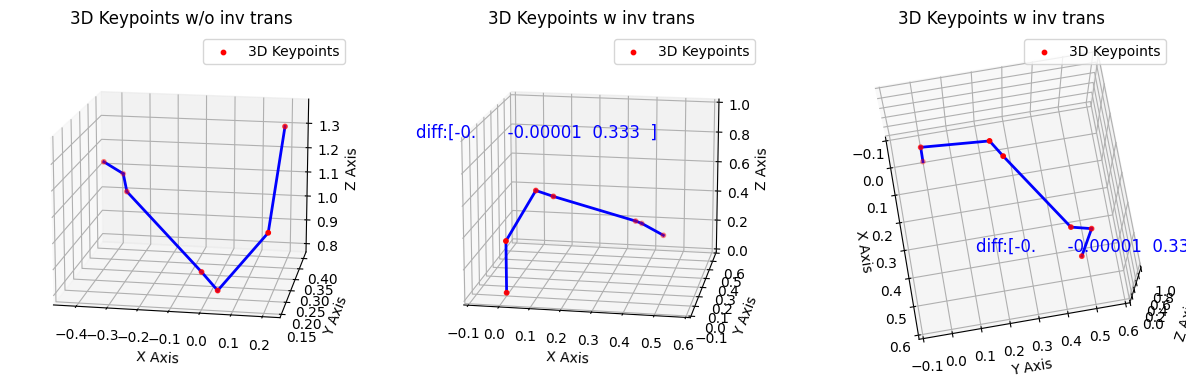

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
np.set_printoptions(suppress=True, precision=5)
# 开启 matplotlib 的交互模式
plt.ion()

# 假设 all_items 已经定义
# all_items = ...

for INDEX in range(0, 50):
    keypoints_3d = all_items['keypoints_3d_original'][INDEX].numpy()  # 假设是 (N, 3) 的形状
    TCO = np.array(all_items["TCO"][INDEX])
    ones = np.expand_dims(np.ones_like(keypoints_3d[:, 0]), 1)
    keypoints_3d_homo = np.concatenate((keypoints_3d, ones), axis=1)
    keypoints_3d_in_obj = np.transpose((np.linalg.inv(TCO) @ keypoints_3d_homo.T))[..., :3]

    # print(f"Trans matrix from object coord --> camera coord: \n{TCO}\n")
    # print(f"keypoints 3d in camera coord: \n{keypoints_3d}\n")
    # print(f"keypoints 3d in object coord: \n{keypoints_3d_in_obj}\n")

    difference = keypoints_3d[1] - keypoints_3d[0]
    difference_trans = keypoints_3d_in_obj[1] - keypoints_3d_in_obj[0]
    # 创建 3D 图形
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(131, projection='3d')

    # 提取 x, y, z 坐标
    x = keypoints_3d[:, 0]
    y = keypoints_3d[:, 1]
    z = keypoints_3d[:, 2]

    # 绘制 3D 点
    ax.scatter(x, y, z, c='r', marker='o', s=10, label='3D Keypoints')

    # 连接 3D 点
    for i in range(len(keypoints_3d) - 1):
        ax.plot([x[i], x[i + 1]], [y[i], y[i + 1]], [z[i], z[i + 1]], c='b', linestyle='-', linewidth=2)

    # 设置图形属性
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    # ax.set_xlim(0, 0.6)
    # ax.set_ylim(0, 0.6)
    # ax.set_zlim(0, 0.6)
    ax.set_title('3D Keypoints w/o inv trans')
    ax.legend()

    ax2 = fig.add_subplot(132, projection='3d')
    xx = keypoints_3d_in_obj[:, 0]
    yy = keypoints_3d_in_obj[:, 1]
    zz = keypoints_3d_in_obj[:, 2]

    ax2.set_xlabel('X Axis')
    ax2.set_ylabel('Y Axis')
    ax2.set_zlabel('Z Axis')
    ax2.set_xlim(-0.1, 0.6)
    ax2.set_ylim(-0.1, 0.6)
    ax2.set_zlim(0, 1)

    ax2.scatter(xx, yy, zz, c='r', marker='o', s=10, label='3D Keypoints')
    ax2.text(0.0, 0.5, 0.8, f'diff:{difference_trans}', fontsize=12, color='blue', ha='center', va='center')
    ax2.set_title('3D Keypoints w inv trans')
    ax2.legend()

    ax3 = fig.add_subplot(133, projection='3d')
    xx = keypoints_3d_in_obj[:, 0]
    yy = keypoints_3d_in_obj[:, 1]
    zz = keypoints_3d_in_obj[:, 2]

    ax3.set_xlabel('X Axis')
    ax3.set_ylabel('Y Axis')
    ax3.set_zlabel('Z Axis')
    ax3.set_xlim(-0.1, 0.6)
    ax3.set_ylim(-0.1, 0.6)
    ax3.set_zlim(0, 1)

    ax3.scatter(xx, yy, zz, c='r', marker='o', s=10, label='3D Keypoints')
    ax3.text(0.5, 0.5, 0.8, f'diff:{difference_trans}', fontsize=12, color='blue', ha='center', va='center')
    ax3.set_title('3D Keypoints w inv trans')
    ax3.legend()
    ax.view_init(elev=15, azim=-80)
    ax2.view_init(elev=15, azim=-80)
    ax3.view_init(elev=75, azim=-10)


    # 连接 3D 点
    for i in range(len(keypoints_3d) - 1):
        ax2.plot([xx[i], xx[i + 1]], [yy[i], yy[i + 1]], [zz[i], zz[i + 1]], c='b', linestyle='-', linewidth=2)
        ax3.plot([xx[i], xx[i + 1]], [yy[i], yy[i + 1]], [zz[i], zz[i + 1]], c='b', linestyle='-', linewidth=2)

    # 显示图形
    display(fig)

    # 清除之前的输出，但保留当前图形
    if INDEX > 0:
        clear_output(wait=True)

    # 暂停一段时间，方便观察
    plt.pause(0.1)

    # 关闭当前图形
    plt.close(fig)

# 关闭交互模式
plt.ioff()

/home/ruihengwang/robot_pose_estim/Holistic-Robot-Pose-Estimation/lib/utils/urdfpytorch/urdf.py:2169: RuntimeWarning: invalid value encountered in divide
  value = value / np.linalg.norm(value)


torch.Size([1, 6])
[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  3.3300000e-01]
 [ 0.0000000e+00 -1.5473222e-12  6.4900005e-01]
 [ 8.2500003e-02 -1.5473222e-12  6.4900005e-01]
 [ 0.0000000e+00  3.3296803e-13  1.0330000e+00]
 [ 8.8000000e-02  3.3296803e-13  1.0330000e+00]
 [ 8.8000000e-02 -7.1490199e-13  9.2600000e-01]]


<Figure size 1500x500 with 0 Axes>

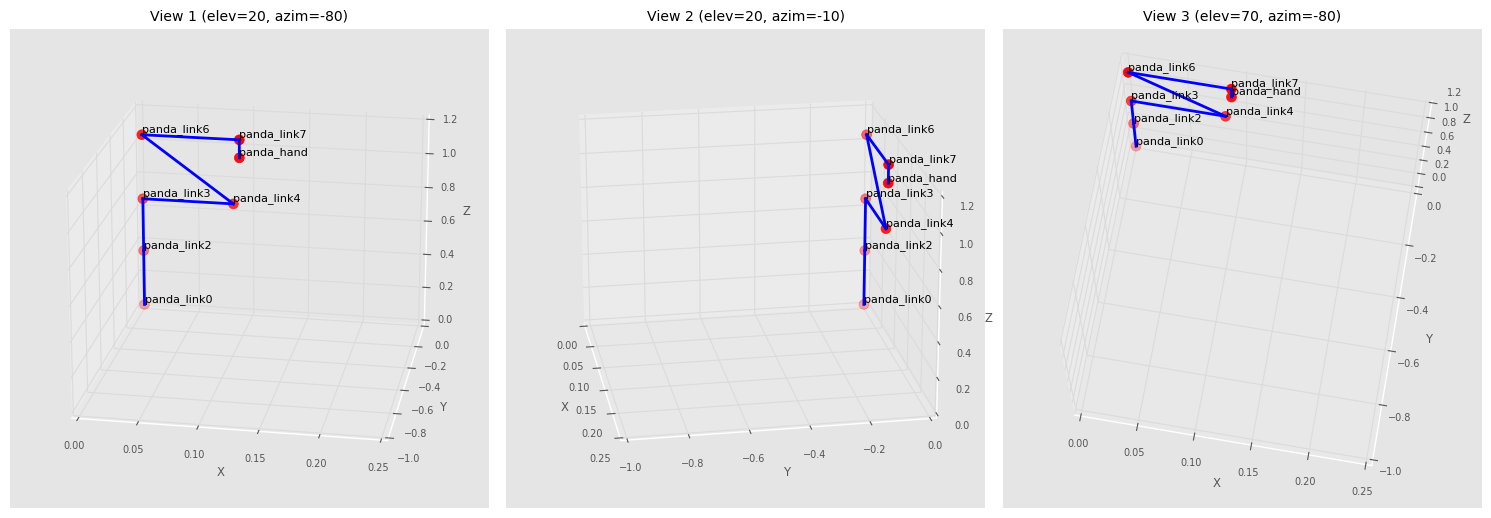

In [29]:
from lib.utils.urdf_robot import URDFRobot
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from lib.utils.geometries import (
    angle_axis_to_rotation_matrix, compute_geodesic_distance_from_two_matrices,
    quat_to_rotmat, rot6d_to_rotmat, rotmat_to_quat, rotmat_to_rot6d)
robot = URDFRobot('panda')
rotate = rotmat_to_rot6d(torch.tensor([[1., 0., 0.],
                                       [0., 1., 0.],
                                       [0., 0., 1.]])).unsqueeze(0)
print(rotate.shape)
joints = torch.tensor([0., 0., 0., 0., 0., 0., 0., 0., ]).unsqueeze(0)
# joints.shape
trans = torch.tensor([0., 0., 0.]).unsqueeze(0)


kp3d_fks = robot.get_keypoints(joints, rotate, trans).squeeze(0).detach().cpu().numpy()
print(kp3d_fks)
# Labels for keypoints
labels = ['panda_link0', 'panda_link2', 'panda_link3', 'panda_link4',
          'panda_link6', 'panda_link7', 'panda_hand']
fig = plt.figure(figsize=(15, 5))

# Define view angles for the three subplots
view_angles = [(20, -80), (20, -10), (70, -80)]
# Extract xyz coordinates
# Create a figure with 1 row and 3 columns for subplots
fig = plt.figure(figsize=(15, 5))

# Define view angles for the three subplots
view_angles = [(20, -80), (20, -10), (70, -80)]

x, y, z = kp3d_fks[:, 0], kp3d_fks[:, 1], kp3d_fks[:, 2]
titles = ["View 1 (elev=20, azim=-80)", "View 2 (elev=20, azim=-10)", "View 3 (elev=70, azim=-80)"]

for i in range(3):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    
    # Scatter plot of keypoints
    ax.scatter(x, y, z, c='r', marker='o', s=50, label="Keypoints")

    # Connect keypoints sequentially with lines
    for j in range(len(x) - 1):
        ax.plot([x[j], x[j+1]], [y[j], y[j+1]], [z[j], z[j+1]], c='b', linewidth=2)

    # Label each point
    for j, label in enumerate(labels):
        ax.text(x[j], y[j], z[j], label, fontsize=8, verticalalignment='bottom')

    # Set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(titles[i])
    ax.set_xlim(0, 0.25)
    ax.set_ylim(-1, 0)
    ax.set_zlim(0, 1.2)

    # Set view angle
    ax.view_init(elev=view_angles[i][0], azim=view_angles[i][1])

# Show the plot
plt.tight_layout()
plt.show()


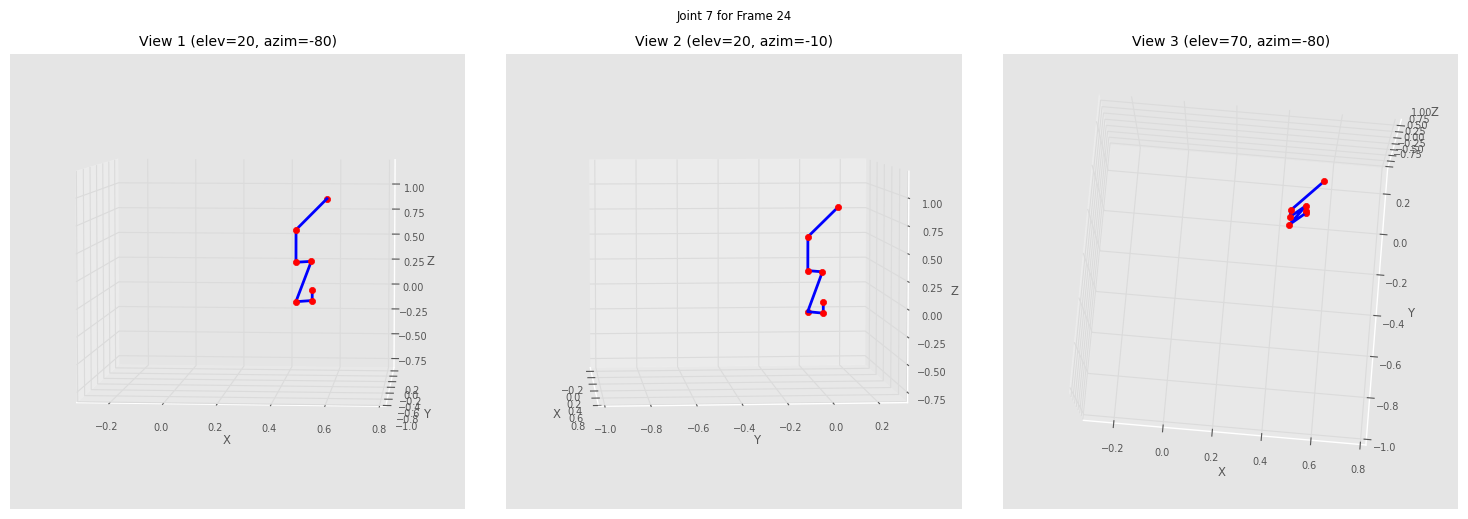

In [92]:
from lib.utils.urdf_robot import URDFRobot
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from IPython.display import clear_output
import time
import math

# 初始化机器人模型
robot = URDFRobot('panda')

# 固定旋转矩阵和位移
rotate = rotmat_to_rot6d(torch.tensor([[1., 0., 0.],
                                       [0., 1., 0.],
                                       [0., 0., 1.]])).unsqueeze(0)
trans = torch.tensor([0.5, 0., 0.]).unsqueeze(0)

# 定义关节角度范围和步数
joint_index = 7 # 修改第一个关节
step_count = 25
joint_values = np.linspace(0, 2*math.pi, step_count)  # 从 -0.5 到 0.5，共 100 个步长

# 用于存储所有标签
labels = ['panda_link0', 'panda_link2', 'panda_link3', 'panda_link4',
          'panda_link6', 'panda_link7', 'panda_hand']

# 动态更新绘图
for frame_idx in range(step_count):
    clear_output(wait=True)  # 清除之前的输出

    # 获取当前关节角度
    joints = torch.zeros(1, 8)  # 初始化关节角度
    # joints[0, 0] = math.pi / 6
    joints[0, 1] = math.pi / 6
    # joints[0, 2] = math.pi / 6
    # joints[0, 4] = math.pi / 2
    # joints[0, 5] = math.pi / 2
    joints[0, joint_index] = joint_values[frame_idx]  # 修改第一个关节的角度

    # 获取关键点
    kp3d_fks = robot.get_keypoints_root(joints, rotate, trans, root=6).squeeze(0).detach().cpu().numpy()
    x, y, z = kp3d_fks[:, 0], kp3d_fks[:, 1], kp3d_fks[:, 2]

    # 每次循环重新创建图形和子图
    fig = plt.figure(figsize=(15, 5))

    # 定义视图角度
    view_angles = [(5, -85), (5, -5), (80, -85)]
    titles = ["View 1 (elev=20, azim=-80)", "View 2 (elev=20, azim=-10)", "View 3 (elev=70, azim=-80)"]

    # 创建子图
    axes = [fig.add_subplot(1, 3, i + 1, projection='3d') for i in range(3)]

    # 绘制每个子图
    for i, ax in enumerate(axes):
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(titles[i])
        ax.set_xlim(-0.3, 0.8)
        ax.set_ylim(-1, 0.3)
        ax.set_zlim(-0.8, 1.2)
        ax.view_init(elev=view_angles[i][0], azim=view_angles[i][1])

        # 绘制点和线
        if len(x) > 1:  # 确保有足够点绘制线
            line, = ax.plot(x, y, z, c='b', linewidth=2)
        for j, label in enumerate(labels):
            ax.scatter(x[j], y[j], z[j], c='r', marker='o', s=20, label=label)

        # 添加标签（避免重复添加）
        if frame_idx == 0:  # 只在第一次绘制时添加标签
            for j, label in enumerate(labels):
                ax.text(x[j], y[j], z[j], label, fontsize=8, verticalalignment='bottom')
    
    plt.suptitle(f'Joint {joint_index} for Frame {frame_idx}', y=1.02)

    # 显示当前图像
    plt.tight_layout()
    plt.show()

    # 暂停一段时间以模拟动画效果
    # time.sleep(0.05)

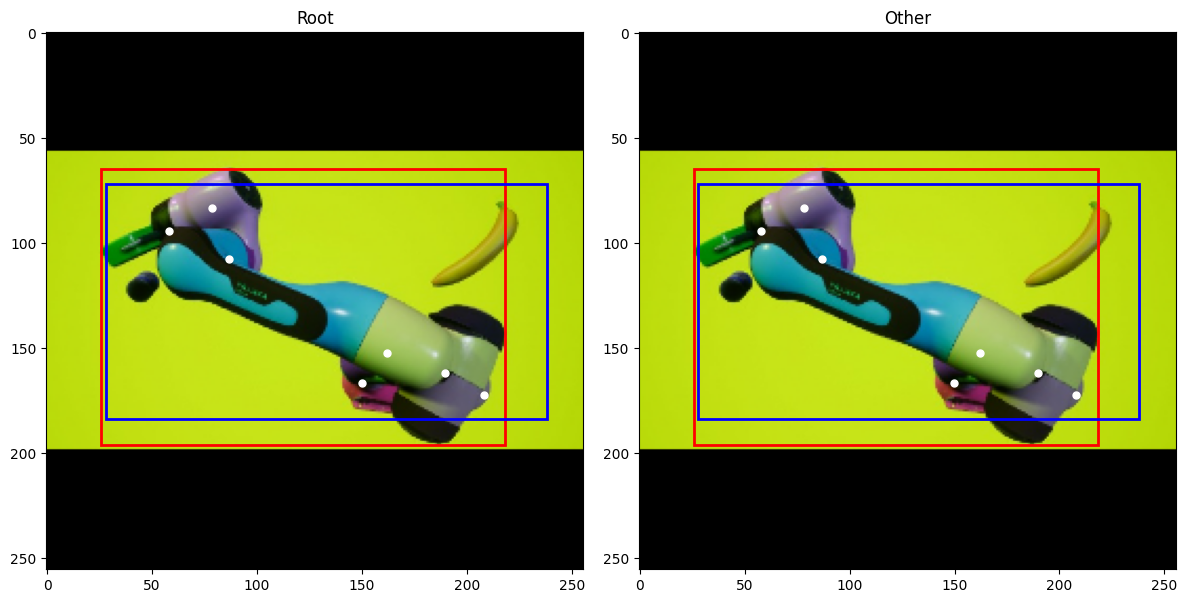

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 访问 all_items['root'] 和 all_items['other'] 中的数据
root_data = all_items['root']
other_data = all_items['other']

# 创建一个 1x2 的子图
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 绘制 root 的图像
# 获取 root 的第一个图像
root_image = root_data['images'][0].permute(1, 2, 0).detach().cpu().numpy().astype(np.uint8)
axes[0].imshow(root_image)

# 获取 root 的 bounding boxes 和 keypoints
root_bbox_strict = root_data['bbox_strict_bounded'][0].numpy()
root_bbox_extended = root_data['bbox_gt2d_extended'][0].numpy()
root_keypoints_2d = root_data['keypoints_2d'][0].numpy()

# 绘制 root 的红色 bounding box
x_min, y_min, x_max, y_max = root_bbox_strict
rect_strict = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                linewidth=2, edgecolor='r', facecolor='none')
axes[0].add_patch(rect_strict)

# 绘制 root 的蓝色 bounding box
x_min, y_min, x_max, y_max = root_bbox_extended
rect_extended = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                  linewidth=2, edgecolor='b', facecolor='none')
axes[0].add_patch(rect_extended)

# 绘制 root 的 keypoints
for point in root_keypoints_2d:
    x, y = point
    axes[0].plot(x, y, 'wo', markersize=5)  # 使用绿色圆点标记 keypoints

# 设置 root 子图的标题
axes[0].set_title('Root')

# 绘制 other 的图像
# 获取 other 的第一个图像
other_image = other_data['images'][0].permute(1, 2, 0).detach().cpu().numpy().astype(np.uint8)
axes[1].imshow(other_image)

# 获取 other 的 bounding boxes 和 keypoints
other_bbox_strict = other_data['bbox_strict_bounded'][0].numpy()
other_bbox_extended = other_data['bbox_gt2d_extended'][0].numpy()
other_keypoints_2d = other_data['keypoints_2d'][0].numpy()

# 绘制 other 的红色 bounding box
x_min, y_min, x_max, y_max = other_bbox_strict
rect_strict = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                linewidth=2, edgecolor='r', facecolor='none')
axes[1].add_patch(rect_strict)

# 绘制 other 的蓝色 bounding box
x_min, y_min, x_max, y_max = other_bbox_extended
rect_extended = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                  linewidth=2, edgecolor='b', facecolor='none')
axes[1].add_patch(rect_extended)

# 绘制 other 的 keypoints
for point in other_keypoints_2d:
    x, y = point
    axes[1].plot(x, y, 'wo', markersize=5)  # 使用绿色圆点标记 keypoints

# 设置 other 子图的标题
axes[1].set_title('Other')

# 显示图像
plt.tight_layout()
plt.show()